# EEP 595 PPML Project Part 3: Colab Experiments

This notebook produces preliminary, reproducible results for the Part 3
progress report. It compares:

- a non-private centralized baseline,
- a DP-SGD-style NumPy prototype,
- an IID federated learning simulation with FedAvg,
- and an HE/encrypted-inference feasibility track.

The experiment intentionally uses `sklearn.datasets.load_digits()` so it runs
quickly in Google Colab without external datasets.

In [ ]:
import math
import os
import subprocess
import sys
import time
import warnings
from pathlib import Path

try:
    get_ipython  # type: ignore[name-defined]
    IN_NOTEBOOK = True
except NameError:
    IN_NOTEBOOK = False

if not IN_NOTEBOOK:
    os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib-cache")
    import matplotlib

    matplotlib.use("Agg")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_digits
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore", category=FutureWarning)

try:
    from IPython.display import display
except ImportError:

    def display(obj):
        print(obj)


SEED = 509
OUTPUT_DIR = Path(".")
np.random.seed(SEED)
rng = np.random.default_rng(SEED)
sns.set_theme(style="whitegrid")

# Set this to True in Colab if you want to attempt the optional TenSEAL demo.
RUN_TENSEAL = True

print(f"Seed: {SEED}")


def show_plot():
    if IN_NOTEBOOK:
        plt.show()
    else:
        plt.close()

Seed: 509


## Dataset

We use the scikit-learn digits dataset: 1,797 grayscale 8x8 images across 10
classes. Pixel values are normalized from `[0, 16]` to `[0, 1]`.

Dataset: 1797 samples, 64 features, 10 classes
Train: 1437 samples, test: 360 samples


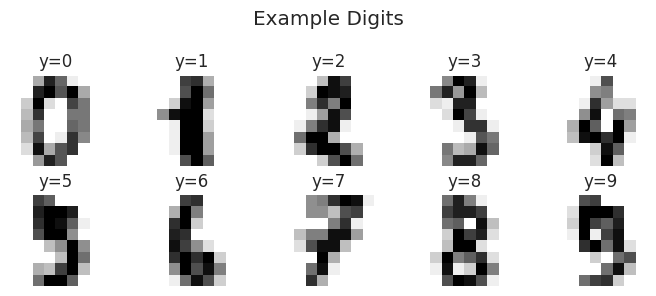

In [ ]:
digits = load_digits()
X = digits.data.astype(np.float64) / 16.0
y = digits.target.astype(int)
NUM_CLASSES = len(np.unique(y))

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=SEED,
)

print(f"Dataset: {X.shape[0]} samples, {X.shape[1]} features, {NUM_CLASSES} classes")
print(f"Train: {X_train.shape[0]} samples, test: {X_test.shape[0]} samples")

fig, axes = plt.subplots(2, 5, figsize=(7, 3))
for ax, image, label in zip(axes.ravel(), digits.images[:10], digits.target[:10]):
    ax.imshow(image, cmap="gray_r")
    ax.set_title(f"y={label}")
    ax.axis("off")
fig.suptitle("Example Digits")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "part3_digits_examples.png", dpi=180)
show_plot()

## Shared Helpers

In [ ]:
def add_bias(X_matrix):
    return np.hstack([X_matrix, np.ones((X_matrix.shape[0], 1))])


def one_hot(labels, num_classes=NUM_CLASSES):
    encoded = np.zeros((len(labels), num_classes), dtype=np.float64)
    encoded[np.arange(len(labels)), labels] = 1.0
    return encoded


def softmax(logits):
    shifted = logits - logits.max(axis=1, keepdims=True)
    exp_logits = np.exp(shifted)
    return exp_logits / exp_logits.sum(axis=1, keepdims=True)


def predict_proba_np(weights, X_matrix):
    return softmax(add_bias(X_matrix) @ weights)


def confidence_membership_auc(train_proba, test_proba):
    """Confidence-threshold membership inference proxy.

    The attack score is the max predicted class probability. Values closer to
    0.5 mean weaker distinguishability between train and test samples.
    """

    scores = np.concatenate([train_proba.max(axis=1), test_proba.max(axis=1)])
    labels = np.concatenate([np.ones(train_proba.shape[0]), np.zeros(test_proba.shape[0])])
    auc = roc_auc_score(labels, scores)
    return max(float(auc), float(1.0 - auc))


def summarize_metrics(method, train_proba, test_proba, runtime_s, notes=""):
    train_pred = train_proba.argmax(axis=1)
    test_pred = test_proba.argmax(axis=1)
    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)
    return {
        "method": method,
        "train_accuracy": train_acc,
        "test_accuracy": test_acc,
        "macro_f1": f1_score(y_test, test_pred, average="macro"),
        "train_test_gap": train_acc - test_acc,
        "mia_auc_confidence": confidence_membership_auc(train_proba, test_proba),
        "runtime_s": runtime_s,
        "notes": notes,
    }


def rounded_results(rows):
    frame = pd.DataFrame(rows)
    numeric_cols = frame.select_dtypes(include=[np.number]).columns
    frame[numeric_cols] = frame[numeric_cols].round(4)
    return frame


results = []

## Centralized Baseline

This is the non-private reference point. Later DP and FL results are compared
against this model.

,method,train_accuracy,test_accuracy,macro_f1,train_test_gap,mia_auc_confidence,runtime_s,notes
0,Centralized logistic regression baseline,0.9861,0.9833,0.9833,0.0027,0.5191,0.3947,Non-private baseline trained with scikit-learn.


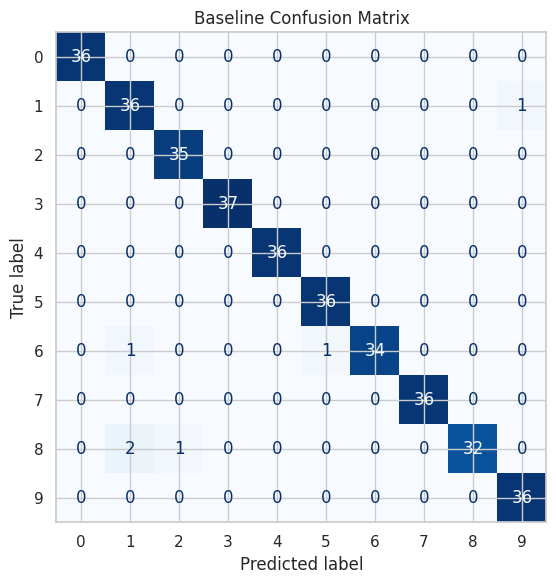

In [ ]:
start = time.perf_counter()
baseline_model = LogisticRegression(max_iter=2000, random_state=SEED)
baseline_model.fit(X_train, y_train)
baseline_runtime = time.perf_counter() - start

baseline_train_proba = baseline_model.predict_proba(X_train)
baseline_test_proba = baseline_model.predict_proba(X_test)
baseline_metrics = summarize_metrics(
    "Centralized logistic regression baseline",
    baseline_train_proba,
    baseline_test_proba,
    baseline_runtime,
    "Non-private baseline trained with scikit-learn.",
)
results.append(baseline_metrics)

display(rounded_results([baseline_metrics]))

cm = confusion_matrix(y_test, baseline_model.predict(X_test))
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm, display_labels=digits.target_names).plot(
    cmap="Blues",
    values_format="d",
    ax=ax,
    colorbar=False,
)
ax.set_title("Baseline Confusion Matrix")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "part3_baseline_confusion_matrix.png", dpi=180)
show_plot()

## DP-SGD-Style Prototype

This section implements softmax logistic regression in NumPy with per-example
gradient clipping and Gaussian noise. It is a preliminary DP-SGD-style
prototype for Part 3 and does not yet include formal epsilon accounting.

,method,train_accuracy,test_accuracy,macro_f1,train_test_gap,mia_auc_confidence,runtime_s,notes,epsilon
0,"DP-SGD-style softmax, noise=0.0",0.9770,0.9778,0.9778,-0.0007,0.5157,0.8590,Epsilon=inf at delta=0.0001 via SGM RDP bound.,NaN
1,"DP-SGD-style softmax, noise=0.5",0.9756,0.9722,0.9718,0.0034,0.5191,0.9001,Epsilon=23.70 at delta=0.0001 via SGM RDP bound.,23.6984
2,"DP-SGD-style softmax, noise=1.0",0.9687,0.9667,0.9667,0.0020,0.5188,0.8497,Epsilon=10.02 at delta=0.0001 via SGM RDP bound.,10.0243
3,"DP-SGD-style softmax, noise=2.0",0.9520,0.9500,0.9500,0.0020,0.5119,0.8153,Epsilon=4.56 at delta=0.0001 via SGM RDP bound.,4.5559


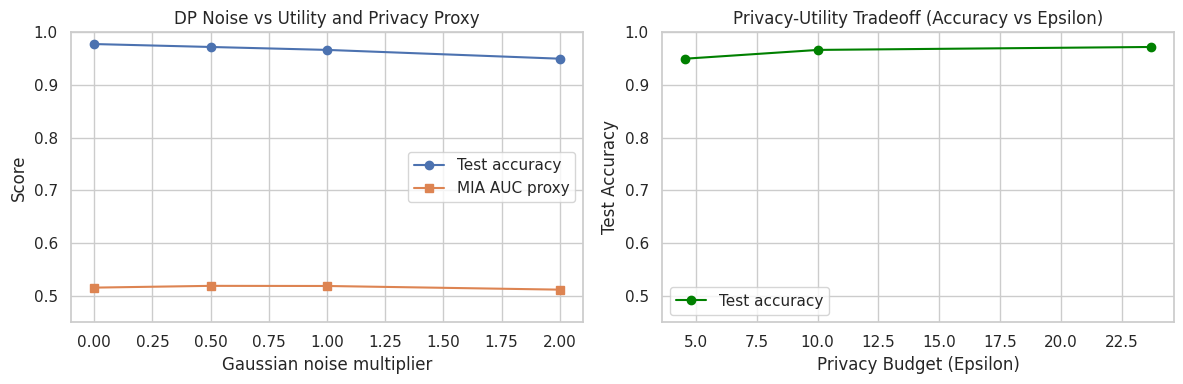

In [ ]:
def train_dp_sgd_softmax(
    X_train_matrix,
    y_train_vector,
    noise_multiplier,
    *,
    epochs=80,
    batch_size=64,
    learning_rate=1.0,
    clip_norm=1.0,
    seed=SEED,
):
    local_rng = np.random.default_rng(seed + int(noise_multiplier * 1000))
    weights = local_rng.normal(
        loc=0.0,
        scale=0.01,
        size=(X_train_matrix.shape[1] + 1, NUM_CLASSES),
    )
    X_bias = add_bias(X_train_matrix)
    n_samples = X_train_matrix.shape[0]
    n_batches = math.ceil(n_samples / batch_size)

    for _ in range(epochs):
        permutation = local_rng.permutation(n_samples)
        for batch_indices in np.array_split(permutation, n_batches):
            X_batch = X_bias[batch_indices]
            y_batch = y_train_vector[batch_indices]
            probs = softmax(X_batch @ weights)
            diff = probs - one_hot(y_batch)

            per_example_grad = X_batch[:, :, None] * diff[:, None, :]
            flat_grad = per_example_grad.reshape(per_example_grad.shape[0], -1)
            grad_norms = np.linalg.norm(flat_grad, axis=1)
            clip_factors = np.minimum(1.0, clip_norm / (grad_norms + 1e-12))
            clipped_grads = per_example_grad * clip_factors[:, None, None]
            grad = clipped_grads.mean(axis=0)

            if noise_multiplier > 0:
                grad += local_rng.normal(
                    loc=0.0,
                    scale=noise_multiplier * clip_norm / len(batch_indices),
                    size=grad.shape,
                )

            weights -= learning_rate * grad

    return weights


def compute_rdp_epsilon(n, batch_size, noise_multiplier, epochs, delta):
    """
    Computes an analytical bound for the privacy budget (epsilon) of DP-SGD.
    Uses the RDP-based asymptotic bound for the Sampled Gaussian Mechanism.
    """
    if noise_multiplier == 0.0:
        return float('inf')

    q = batch_size / n
    steps = int(epochs * math.ceil(n / batch_size))

    alpha_opt = 1 + noise_multiplier * math.sqrt(2 * math.log(1/delta) / (steps * q**2))

    rdp_term = steps * (q**2 * alpha_opt) / (2 * noise_multiplier**2)
    delta_term = math.log(1/delta) / (alpha_opt - 1)

    return rdp_term + delta_term

dp_rows = []
dp_noise_multipliers = [0.0, 0.5, 1.0, 2.0]
TARGET_DELTA = 1e-4

for noise in dp_noise_multipliers:
    start = time.perf_counter()
    dp_weights = train_dp_sgd_softmax(X_train, y_train, noise_multiplier=noise)
    runtime = time.perf_counter() - start

    epsilon = compute_rdp_epsilon(
        n=X_train.shape[0],
        batch_size=64,
        noise_multiplier=noise,
        epochs=80,
        delta=TARGET_DELTA
    )

    train_proba = predict_proba_np(dp_weights, X_train)
    test_proba = predict_proba_np(dp_weights, X_test)

    eps_str = "inf" if math.isinf(epsilon) else f"{epsilon:.2f}"

    row = summarize_metrics(
        f"DP-SGD-style softmax, noise={noise}",
        train_proba,
        test_proba,
        runtime,
        f"Epsilon={eps_str} at delta={TARGET_DELTA} via SGM RDP bound.",
    )
    row["epsilon"] = epsilon if not math.isinf(epsilon) else np.nan
    results.append(row)
    dp_rows.append(row)

dp_results = rounded_results(dp_rows)
display(dp_results)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(
    dp_noise_multipliers,
    [row["test_accuracy"] for row in dp_rows],
    marker="o",
    label="Test accuracy",
)
ax1.plot(
    dp_noise_multipliers,
    [row["mia_auc_confidence"] for row in dp_rows],
    marker="s",
    label="MIA AUC proxy",
)
ax1.set_xlabel("Gaussian noise multiplier")
ax1.set_ylabel("Score")
ax1.set_title("DP Noise vs Utility and Privacy Proxy")
ax1.set_ylim(0.45, 1.0)
ax1.legend()

finite_dp_rows = [r for r in dp_rows if not np.isnan(r["epsilon"])]
epsilons = [r["epsilon"] for r in finite_dp_rows]
accs = [r["test_accuracy"] for r in finite_dp_rows]

ax2.plot(
    epsilons,
    accs,
    marker="o",
    color="green",
    label="Test accuracy",
)
ax2.set_xlabel("Privacy Budget (Epsilon)")
ax2.set_ylabel("Test Accuracy")
ax2.set_title("Privacy-Utility Tradeoff (Accuracy vs Epsilon)")
ax2.set_ylim(0.45, 1.0)
ax2.legend()

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "part3_dp_noise_curve.png", dpi=180)
show_plot()

## Federated Learning Simulation

This simulation uses the same softmax model, splits the training set into five
IID clients, trains locally, and aggregates with FedAvg.

IID Client sizes: [291, 289, 287, 286, 284]


,round,train_accuracy,test_accuracy
25,26,0.967989,0.966667
26,27,0.970077,0.972222
27,28,0.970077,0.969444
28,29,0.971468,0.966667
29,30,0.971468,0.969444


,method,train_accuracy,test_accuracy,macro_f1,train_test_gap,mia_auc_confidence,runtime_s,notes
0,"Federated learning FedAvg, 5 IID clients",0.9715,0.9694,0.9693,0.002,0.5134,0.739,FedAvg with 30 rounds and 2 local epochs per r...


Non-IID Client sizes: [282, 291, 289, 284, 291]


,round,train_accuracy,test_accuracy
25,26,0.931802,0.958333
26,27,0.932498,0.955556
27,28,0.934586,0.955556
28,29,0.934586,0.955556
29,30,0.933890,0.955556


,method,train_accuracy,test_accuracy,macro_f1,train_test_gap,mia_auc_confidence,runtime_s,notes
0,"Federated learning FedAvg, 5 non-IID clients",0.9339,0.9556,0.9554,-0.0217,0.5111,1.0106,Pathological non-IID: 2 digit classes per client.


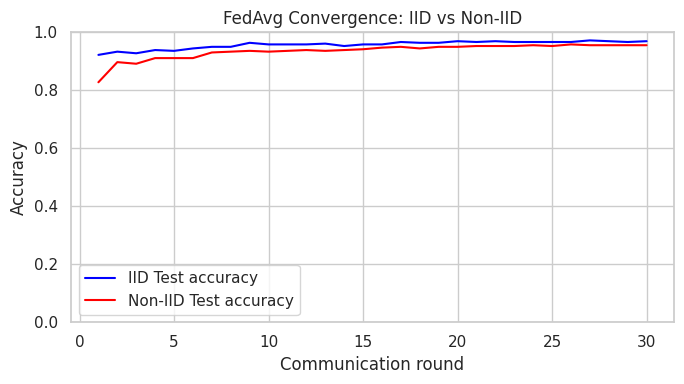

In [ ]:
def make_iid_clients(labels, num_clients=5, seed=SEED):
    local_rng = np.random.default_rng(seed)
    clients = [[] for _ in range(num_clients)]
    for cls in np.unique(labels):
        cls_indices = np.where(labels == cls)[0]
        local_rng.shuffle(cls_indices)
        for client_id, part in enumerate(np.array_split(cls_indices, num_clients)):
            clients[client_id].extend(part.tolist())
    return [np.array(sorted(indices)) for indices in clients]


def make_non_iid_clients(labels, num_clients=5, classes_per_client=2, seed=SEED):
    local_rng = np.random.default_rng(seed)
    clients = [[] for _ in range(num_clients)]

    classes = np.unique(labels)
    shards = []
    for cls in classes:
        cls_indices = np.where(labels == cls)[0]
        local_rng.shuffle(cls_indices)
        shards.append(cls_indices.tolist())

    local_rng.shuffle(shards)

    shard_idx = 0
    for client_id in range(num_clients):
        for _ in range(classes_per_client):
            if shard_idx < len(shards):
                clients[client_id].extend(shards[shard_idx])
                shard_idx += 1

    return [np.array(sorted(indices)) for indices in clients]


def local_train_softmax(
    global_weights,
    X_client,
    y_client,
    *,
    local_epochs=2,
    learning_rate=0.5,
    batch_size=32,
    rng_for_training=None,
):
    if rng_for_training is None:
        rng_for_training = np.random.default_rng(SEED)

    weights = global_weights.copy()
    X_bias = add_bias(X_client)
    n_samples = X_client.shape[0]
    n_batches = math.ceil(n_samples / batch_size)

    for _ in range(local_epochs):
        permutation = rng_for_training.permutation(n_samples)
        for batch_indices in np.array_split(permutation, n_batches):
            probs = softmax(X_bias[batch_indices] @ weights)
            diff = probs - one_hot(y_client[batch_indices])
            grad = X_bias[batch_indices].T @ diff / len(batch_indices)
            weights -= learning_rate * grad

    return weights


def fedavg_train(
    X_train_matrix,
    y_train_vector,
    *,
    num_clients=5,
    rounds=30,
    local_epochs=2,
    learning_rate=0.5,
    batch_size=32,
    seed=SEED,
    iid=True,
):
    local_rng = np.random.default_rng(seed)
    if iid:
        clients = make_iid_clients(y_train_vector, num_clients=num_clients, seed=seed)
    else:
        clients = make_non_iid_clients(y_train_vector, num_clients=num_clients, seed=seed)
    weights = local_rng.normal(
        loc=0.0,
        scale=0.01,
        size=(X_train_matrix.shape[1] + 1, NUM_CLASSES),
    )
    history = []

    for round_id in range(1, rounds + 1):
        client_weights = []
        client_sizes = []

        for client_indices in clients:
            updated_weights = local_train_softmax(
                weights,
                X_train_matrix[client_indices],
                y_train_vector[client_indices],
                local_epochs=local_epochs,
                learning_rate=learning_rate,
                batch_size=batch_size,
                rng_for_training=local_rng,
            )
            client_weights.append(updated_weights)
            client_sizes.append(len(client_indices))

        total_size = sum(client_sizes)
        weights = sum(
            (size / total_size) * client_weight
            for size, client_weight in zip(client_sizes, client_weights)
        )

        train_proba = predict_proba_np(weights, X_train)
        test_proba = predict_proba_np(weights, X_test)
        history.append(
            {
                "round": round_id,
                "train_accuracy": accuracy_score(y_train, train_proba.argmax(axis=1)),
                "test_accuracy": accuracy_score(y_test, test_proba.argmax(axis=1)),
            }
        )

    return weights, pd.DataFrame(history), clients


start = time.perf_counter()
fl_weights, fl_history, fl_clients = fedavg_train(X_train, y_train, iid=True)
fl_runtime = time.perf_counter() - start

fl_train_proba = predict_proba_np(fl_weights, X_train)
fl_test_proba = predict_proba_np(fl_weights, X_test)
fl_metrics = summarize_metrics(
    "Federated learning FedAvg, 5 IID clients",
    fl_train_proba,
    fl_test_proba,
    fl_runtime,
    "FedAvg with 30 rounds and 2 local epochs per round.",
)
if "epsilon" in results[0]:
    fl_metrics["epsilon"] = np.nan
results.append(fl_metrics)

client_sizes = [len(client_indices) for client_indices in fl_clients]
print(f"IID Client sizes: {client_sizes}")
display(fl_history.tail())
display(rounded_results([fl_metrics]))

start = time.perf_counter()
fl_noniid_weights, fl_noniid_history, fl_noniid_clients = fedavg_train(X_train, y_train, iid=False)
fl_noniid_runtime = time.perf_counter() - start

fl_noniid_train_proba = predict_proba_np(fl_noniid_weights, X_train)
fl_noniid_test_proba = predict_proba_np(fl_noniid_weights, X_test)
fl_noniid_metrics = summarize_metrics(
    "Federated learning FedAvg, 5 non-IID clients",
    fl_noniid_train_proba,
    fl_noniid_test_proba,
    fl_noniid_runtime,
    "Pathological non-IID: 2 digit classes per client.",
)
if "epsilon" in results[0]:
    fl_noniid_metrics["epsilon"] = np.nan
results.append(fl_noniid_metrics)

print(f"Non-IID Client sizes: {[len(c) for c in fl_noniid_clients]}")
display(fl_noniid_history.tail())
display(rounded_results([fl_noniid_metrics]))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(fl_history["round"], fl_history["test_accuracy"], label="IID Test accuracy", color="blue")
ax.plot(fl_noniid_history["round"], fl_noniid_history["test_accuracy"], label="Non-IID Test accuracy", color="red")
ax.set_xlabel("Communication round")
ax.set_ylabel("Accuracy")
ax.set_title("FedAvg Convergence: IID vs Non-IID")
ax.set_ylim(0.0, 1.0)
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "part3_fl_accuracy_curve.png", dpi=180)
show_plot()

## HE / Encrypted Inference Feasibility

The Part 3 minimum is a feasibility and runtime track. HE is treated as an
inference-oriented technique because training under HE is usually much more
expensive and requires specialized model design.

TenSEAL is now enabled by default to generate the runtime comparison.

In [ ]:
def he_feasibility_summary():
    sample = X_test[0:1]
    repeats = 1000

    start = time.perf_counter()
    for _ in range(repeats):
        baseline_model.decision_function(sample)
    plaintext_avg_ms = (time.perf_counter() - start) * 1000 / repeats

    rows = [
        {
            "track": "Plaintext baseline inference",
            "status": "measured",
            "avg_latency_ms": plaintext_avg_ms,
            "privacy_property": "None; raw features are visible to the model owner.",
            "part3_interpretation": "Fast utility reference point.",
        },
        {
            "track": "HE encrypted linear inference",
            "status": "planned or optional TenSEAL stretch",
            "avg_latency_ms": np.nan,
            "privacy_property": "Can hide client features during inference under an HE scheme.",
            "part3_interpretation": "Expected to be much slower; best framed as inference-only feasibility.",
        },
    ]
    return pd.DataFrame(rows)


he_summary = he_feasibility_summary()
display(he_summary)

,track,status,avg_latency_ms,privacy_property,part3_interpretation
0,Plaintext baseline inference,measured,0.114679,None; raw features are visible to the model ow...,Fast utility reference point.
1,HE encrypted linear inference,planned or optional TenSEAL stretch,NaN,Can hide client features during inference unde...,Expected to be much slower; best framed as inf...


,status,encrypted_runtime_s,max_abs_logit_error,plaintext_prediction,encrypted_prediction
0,completed,0.215103,0.000001,5,5



Updated HE Summary with measured latency:


,track,status,avg_latency_ms,privacy_property,part3_interpretation
0,Plaintext baseline inference,measured,0.114679,None; raw features are visible to the model ow...,Fast utility reference point.
1,HE encrypted linear inference,measured,215.102673,Can hide client features during inference unde...,Expected to be much slower; best framed as inf...


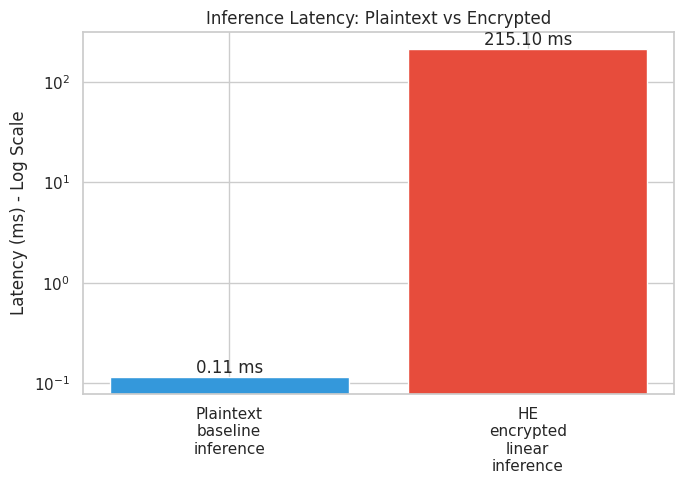

In [ ]:
def optional_tenseal_demo():
    if not RUN_TENSEAL:
        return pd.DataFrame(
            [
                {
                    "status": "skipped",
                    "detail": "Set RUN_TENSEAL=True in Colab to attempt installation and encrypted inference.",
                }
            ]
        )

    try:
        import tenseal as ts
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "tenseal"])
        import tenseal as ts

    sample = X_test[0]
    plaintext_logits = baseline_model.decision_function(sample.reshape(1, -1))[0]

    context = ts.context(
        ts.SCHEME_TYPE.CKKS,
        poly_modulus_degree=8192,
        coeff_mod_bit_sizes=[60, 40, 40, 60],
    )
    context.global_scale = 2**40
    context.generate_galois_keys()

    start = time.perf_counter()
    encrypted_sample = ts.ckks_vector(context, sample.tolist())
    encrypted_logits = [
        encrypted_sample.dot(weight_vector.tolist()) + float(bias)
        for weight_vector, bias in zip(baseline_model.coef_, baseline_model.intercept_)
    ]
    decrypted_logits = np.array([value.decrypt()[0] for value in encrypted_logits])
    encrypted_runtime_s = time.perf_counter() - start

    return pd.DataFrame(
        [
            {
                "status": "completed",
                "encrypted_runtime_s": encrypted_runtime_s,
                "max_abs_logit_error": float(np.max(np.abs(plaintext_logits - decrypted_logits))),
                "plaintext_prediction": int(np.argmax(plaintext_logits)),
                "encrypted_prediction": int(np.argmax(decrypted_logits)),
            }
        ]
    )


tenseal_result = optional_tenseal_demo()
display(tenseal_result)

if RUN_TENSEAL and "encrypted_runtime_s" in tenseal_result.columns:
    enc_ms = tenseal_result.iloc[0]["encrypted_runtime_s"] * 1000
    he_summary.loc[1, "avg_latency_ms"] = enc_ms
    he_summary.loc[1, "status"] = "measured"

    print("\nUpdated HE Summary with measured latency:")
    display(he_summary)

    fig, ax = plt.subplots(figsize=(7, 5))
    tracks = he_summary["track"].str.replace(" ", "\n")
    latencies = he_summary["avg_latency_ms"]

    bars = ax.bar(tracks, latencies, color=["#3498db", "#e74c3c"])
    ax.set_yscale("log")
    ax.set_ylabel("Latency (ms) - Log Scale")
    ax.set_title("Inference Latency: Plaintext vs Encrypted")

    # Add values on top of bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f"{height:.2f} ms",
                ha='center', va='bottom')

    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "part3_he_latency_comparison.png", dpi=180)
    show_plot()

## Final Result Table for the Progress Report

Use this table directly in the Part 3 report. The strongest concise story is:

1. The centralized baseline establishes the utility target.
2. The DP-SGD-style prototype shows the expected privacy/utility tension.
3. FedAvg reaches similar utility under an IID client split.
4. HE is currently scoped as encrypted inference feasibility, not training.

In [ ]:
final_results = rounded_results(results)
display(final_results)
final_results.to_csv(OUTPUT_DIR / "part3_results_table.csv", index=False)
fl_history.to_csv(OUTPUT_DIR / "part3_fl_history.csv", index=False)
he_summary.to_csv(OUTPUT_DIR / "part3_he_feasibility.csv", index=False)

print("Saved outputs:")
for filename in [
    "part3_digits_examples.png",
    "part3_baseline_confusion_matrix.png",
    "part3_dp_noise_curve.png",
    "part3_fl_accuracy_curve.png",
    "part3_he_latency_comparison.png",
    "part3_results_table.csv",
    "part3_fl_history.csv",
    "part3_he_feasibility.csv",
]:
    print(f"- {filename}")

,method,train_accuracy,test_accuracy,macro_f1,train_test_gap,mia_auc_confidence,runtime_s,notes,epsilon
0,Centralized logistic regression baseline,0.9861,0.9833,0.9833,0.0027,0.5191,0.3947,Non-private baseline trained with scikit-learn.,NaN
1,"DP-SGD-style softmax, noise=0.0",0.9770,0.9778,0.9778,-0.0007,0.5157,0.8590,Epsilon=inf at delta=0.0001 via SGM RDP bound.,NaN
2,"DP-SGD-style softmax, noise=0.5",0.9756,0.9722,0.9718,0.0034,0.5191,0.9001,Epsilon=23.70 at delta=0.0001 via SGM RDP bound.,23.6984
3,"DP-SGD-style softmax, noise=1.0",0.9687,0.9667,0.9667,0.0020,0.5188,0.8497,Epsilon=10.02 at delta=0.0001 via SGM RDP bound.,10.0243
4,"DP-SGD-style softmax, noise=2.0",0.9520,0.9500,0.9500,0.0020,0.5119,0.8153,Epsilon=4.56 at delta=0.0001 via SGM RDP bound.,4.5559
5,"Federated learning FedAvg, 5 IID clients",0.9715,0.9694,0.9693,0.0020,0.5134,0.7390,FedAvg with 30 rounds and 2 local epochs per r...,NaN
6,"Federated learning FedAvg, 5 non-IID clients",0.9339,0.9556,0.9554,-0.0217,0.5111,1.0106,Pathological non-IID: 2 digit classes per client.,NaN


Saved outputs:
- part3_digits_examples.png
- part3_baseline_confusion_matrix.png
- part3_dp_noise_curve.png
- part3_fl_accuracy_curve.png
- part3_he_latency_comparison.png
- part3_results_table.csv
- part3_fl_history.csv
- part3_he_feasibility.csv
